In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

# Sklearn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, accuracy_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)

# Models
import xgboost as xgb


# Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Persistence
import joblib

# Paths
DATA_PROCESSED = Path('../data/processed/')
MODELS_PATH    = Path('../models/')
FIGURES_PATH   = Path('../notebooks/figures/')
MODELS_PATH.mkdir(exist_ok=True)

print("✓ All imports successful")

✓ All imports successful


In [ ]:
X = pd.read_parquet(DATA_PROCESSED / 'X_features.parquet')
y = pd.read_parquet(DATA_PROCESSED / 'y_target.parquet')['churn']

with open(DATA_PROCESSED / 'feature_names.json') as f:
    feature_names = json.load(f)

print(f"X shape        : {X.shape}")
print(f"y shape        : {y.shape}")
print(f"Churn rate     : {y.mean():.1%}")
print(f"Features       : {len(feature_names)}")
print(f"\nClass distribution :")
print(f"  No Churn (0) : {(y==0).sum():,} ({(y==0).mean():.1%})")
print(f"  Churn    (1) : {(y==1).sum():,} ({(y==1).mean():.1%})")

# Class imbalance ratio — needed for XGBoost
neg = (y == 0).sum()
pos = (y == 1).sum()
scale_pos_weight = neg / pos
print(f"\nscale_pos_weight : {scale_pos_weight:.2f}")
print("(Used to handle class imbalance in XGBoost)")

X shape        : (15025, 36)
y shape        : (15025,)
Churn rate     : 47.4%
Features       : 36

Class distribution :
  No Churn (0) : 7,898 (52.6%)
  Churn    (1) : 7,127 (47.4%)

scale_pos_weight : 1.11
(Used to handle class imbalance in XGBoost)


In [ ]:
print("── TRAIN / TEST SPLIT ──")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # Critical for imbalanced datasets
)

print(f"Train set : {X_train.shape[0]:,} rows "
      f"({X_train.shape[0]/len(X):.0%})")
print(f"Test set  : {X_test.shape[0]:,} rows "
      f"({X_test.shape[0]/len(X):.0%})")

print(f"\nChurn rate — Train : {y_train.mean():.1%}")
print(f"Churn rate — Test  : {y_test.mean():.1%}")
print("→ Rates should be equal — stratify=y confirms this")

# Cross-validation strategy — used for ALL models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"\nCross-validation : StratifiedKFold(n_splits=5)")
print("→ Each fold preserves the churn rate distribution")

── TRAIN / TEST SPLIT ──
Train set : 12,020 rows (80%)
Test set  : 3,005 rows (20%)

Churn rate — Train : 47.4%
Churn rate — Test  : 47.4%
→ Rates should be equal — stratify=y confirms this

Cross-validation : StratifiedKFold(n_splits=5)
→ Each fold preserves the churn rate distribution


In [ ]:
print("── SKLEARN PIPELINE ──")

# Identify column types
# These columns already encoded as int in feature engineering
binary_cols = [
    'senior_citizen', 'has_partner', 'has_dependents',
    'paperless_billing', 'is_new_customer',
    'has_fiber_no_support', 'has_fiber_with_support',
    'senior_alone'
]

# Numeric continuous columns
numeric_cols = [
    'age', 'tenure_months', 'monthly_charges',
    'total_charges', 'charges_per_month',
    'service_value_ratio', 'num_services'
]

# Ordinal / risk score columns
ordinal_cols = [
    'contract_risk_score', 'payment_risk_score',
    'tenure_contract_risk'
]

# One-hot encoded columns already in X
# (created by get_dummies in feature engineering)
ohe_cols = [c for c in X.columns
            if c not in binary_cols
            and c not in numeric_cols
            and c not in ordinal_cols]

print(f"Binary columns   : {len(binary_cols)}")
print(f"Numeric columns  : {len(numeric_cols)}")
print(f"Ordinal columns  : {len(ordinal_cols)}")
print(f"OHE columns      : {len(ohe_cols)}")
print(f"Total features   : {X.shape[1]}")

# Preprocessor — fits on train, transforms both
# This is the SAME object saved for the API
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('bin', 'passthrough', binary_cols),
        ('ord', 'passthrough', ordinal_cols),
        ('ohe', 'passthrough', ohe_cols),
    ],
    remainder='drop'
)

print("\n✓ Preprocessor defined")
print("→ StandardScaler on numeric only")
print("→ Binary/ordinal/OHE passed through as-is")

── SKLEARN PIPELINE ──
Binary columns   : 8
Numeric columns  : 7
Ordinal columns  : 3
OHE columns      : 18
Total features   : 36

✓ Preprocessor defined
→ StandardScaler on numeric only
→ Binary/ordinal/OHE passed through as-is


In [ ]:
def evaluate_model(
    name: str,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray
) -> dict:
    """
    Compute all relevant metrics for a classifier.
    Returns a dict for easy comparison across models.
    """
    return {
        'Model'       : name,
        'AUC-ROC'     : round(roc_auc_score(y_true, y_proba), 4),
        'PR-AUC'      : round(average_precision_score(
                            y_true, y_proba), 4),
        'F1'          : round(f1_score(y_true, y_pred), 4),
        'Precision'   : round(precision_score(y_true, y_pred), 4),
        'Recall'      : round(recall_score(y_true, y_pred), 4),
        'Accuracy'    : round(accuracy_score(y_true, y_pred), 4),
    }


def cross_val_evaluate(
    name: str,
    pipeline: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    cv: StratifiedKFold
) -> dict:
    """
    Run cross-validation and return mean ± std metrics.
    """
    scoring = ['roc_auc', 'f1', 'average_precision']
    results = cross_validate(
        pipeline, X, y,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    return {
        'Model'           : name,
        'CV AUC-ROC'      : f"{results['test_roc_auc'].mean():.4f}"
                            f" ± {results['test_roc_auc'].std():.4f}",
        'CV PR-AUC'       : f"{results['test_average_precision'].mean():.4f}"
                            f" ± {results['test_average_precision'].std():.4f}",
        'CV F1'           : f"{results['test_f1'].mean():.4f}"
                            f" ± {results['test_f1'].std():.4f}",
        '_auc_mean'       : results['test_roc_auc'].mean(),
    }

print("✓ Evaluation functions defined")

✓ Evaluation functions defined


In [ ]:
print("── BASELINE : DummyClassifier (majority class) ──")
print("This is the floor. Every model must beat this.")

dummy_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', DummyClassifier(
        strategy='most_frequent',
        random_state=42
    ))
])

dummy_pipeline.fit(X_train, y_train)
y_pred_dummy  = dummy_pipeline.predict(X_test)
y_proba_dummy = dummy_pipeline.predict_proba(X_test)[:, 1]

baseline_results = evaluate_model(
    'DummyClassifier',
    y_test, y_pred_dummy, y_proba_dummy
)

print(f"\nResults on test set :")
for metric, value in baseline_results.items():
    if metric != 'Model':
        print(f"  {metric:<12} : {value}")

print(f"\n→ AUC-ROC = 0.5 confirms random performance")
print(f"→ F1 = 0.0 because it never predicts churn")
print(f"→ Accuracy = {1 - y_test.mean():.1%} — "
      f"misleading metric confirmed")

── BASELINE : DummyClassifier (majority class) ──
This is the floor. Every model must beat this.

Results on test set :
  AUC-ROC      : 0.5
  PR-AUC       : 0.4742
  F1           : 0.0
  Precision    : 0.0
  Recall       : 0.0
  Accuracy     : 0.5258

→ AUC-ROC = 0.5 confirms random performance
→ F1 = 0.0 because it never predicts churn
→ Accuracy = 52.6% — misleading metric confirmed


In [ ]:
print("── MODEL 2 : Logistic Regression ──")
print("Strong interpretable baseline.")
print("If LR is close to XGBoost → problem is nearly linear.")

lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',   # handles imbalance
        random_state=42,
        solver='lbfgs'
    ))
])

# Cross-validation first
print("\nRunning 5-fold cross-validation...")
lr_cv = cross_val_evaluate(
    'Logistic Regression',
    lr_pipeline, X_train, y_train, cv
)
print(f"  CV AUC-ROC : {lr_cv['CV AUC-ROC']}")
print(f"  CV PR-AUC  : {lr_cv['CV PR-AUC']}")
print(f"  CV F1      : {lr_cv['CV F1']}")

# Fit on full train set
lr_pipeline.fit(X_train, y_train)
y_pred_lr  = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

lr_results = evaluate_model(
    'Logistic Regression',
    y_test, y_pred_lr, y_proba_lr
)

print(f"\nTest set results :")
for metric, value in lr_results.items():
    if metric != 'Model':
        print(f"  {metric:<12} : {value}")

── MODEL 2 : Logistic Regression ──
Strong interpretable baseline.
If LR is close to XGBoost → problem is nearly linear.

Running 5-fold cross-validation...
  CV AUC-ROC : 0.8621 ± 0.0030
  CV PR-AUC  : 0.8410 ± 0.0064
  CV F1      : 0.7790 ± 0.0066

Test set results :
  AUC-ROC      : 0.8567
  PR-AUC       : 0.8377
  F1           : 0.7783
  Precision    : 0.7393
  Recall       : 0.8218
  Accuracy     : 0.778


In [ ]:
print("── MODEL 3 : Random Forest ──")
print("Non-linear ensemble — good reference before XGBoost.")

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

print("\nRunning 5-fold cross-validation...")
rf_cv = cross_val_evaluate(
    'Random Forest',
    rf_pipeline, X_train, y_train, cv
)
print(f"  CV AUC-ROC : {rf_cv['CV AUC-ROC']}")
print(f"  CV PR-AUC  : {rf_cv['CV PR-AUC']}")
print(f"  CV F1      : {rf_cv['CV F1']}")

rf_pipeline.fit(X_train, y_train)
y_pred_rf  = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

rf_results = evaluate_model(
    'Random Forest',
    y_test, y_pred_rf, y_proba_rf
)

print(f"\nTest set results :")
for metric, value in rf_results.items():
    if metric != 'Model':
        print(f"  {metric:<12} : {value}")

── MODEL 3 : Random Forest ──
Non-linear ensemble — good reference before XGBoost.

Running 5-fold cross-validation...
  CV AUC-ROC : 0.8628 ± 0.0031
  CV PR-AUC  : 0.8399 ± 0.0093
  CV F1      : 0.7773 ± 0.0064

Test set results :
  AUC-ROC      : 0.8558
  PR-AUC       : 0.8337
  F1           : 0.7786
  Precision    : 0.7479
  Recall       : 0.8119
  Accuracy     : 0.781


In [ ]:
print("── MODEL 4 : XGBoost (baseline, no tuning) ──")

xgb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric='auc',
        random_state=42,
        n_jobs=-1
    ))
])

print("\nRunning 5-fold cross-validation...")
xgb_cv = cross_val_evaluate(
    'XGBoost (baseline)',
    xgb_pipeline, X_train, y_train, cv
)
print(f"  CV AUC-ROC : {xgb_cv['CV AUC-ROC']}")
print(f"  CV PR-AUC  : {xgb_cv['CV PR-AUC']}")
print(f"  CV F1      : {xgb_cv['CV F1']}")

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb  = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

xgb_results = evaluate_model(
    'XGBoost (baseline)',
    y_test, y_pred_xgb, y_proba_xgb
)

print(f"\nTest set results :")
for metric, value in xgb_results.items():
    if metric != 'Model':
        print(f"  {metric:<12} : {value}")

── MODEL 4 : XGBoost (baseline, no tuning) ──

Running 5-fold cross-validation...
  CV AUC-ROC : 0.8595 ± 0.0022
  CV PR-AUC  : 0.8343 ± 0.0094
  CV F1      : 0.7765 ± 0.0073

Test set results :
  AUC-ROC      : 0.8544
  PR-AUC       : 0.8343
  F1           : 0.7773
  Precision    : 0.7497
  Recall       : 0.807
  Accuracy     : 0.7807


── MODEL COMPARISON ──
                     AUC-ROC  PR-AUC      F1  Precision  Recall  Accuracy
Model                                                                    
DummyClassifier       0.5000  0.4742  0.0000     0.0000  0.0000    0.5258
Logistic Regression   0.8567  0.8377  0.7783     0.7393  0.8218    0.7780
Random Forest         0.8558  0.8337  0.7786     0.7479  0.8119    0.7810
XGBoost (baseline)    0.8544  0.8343  0.7773     0.7497  0.8070    0.7807


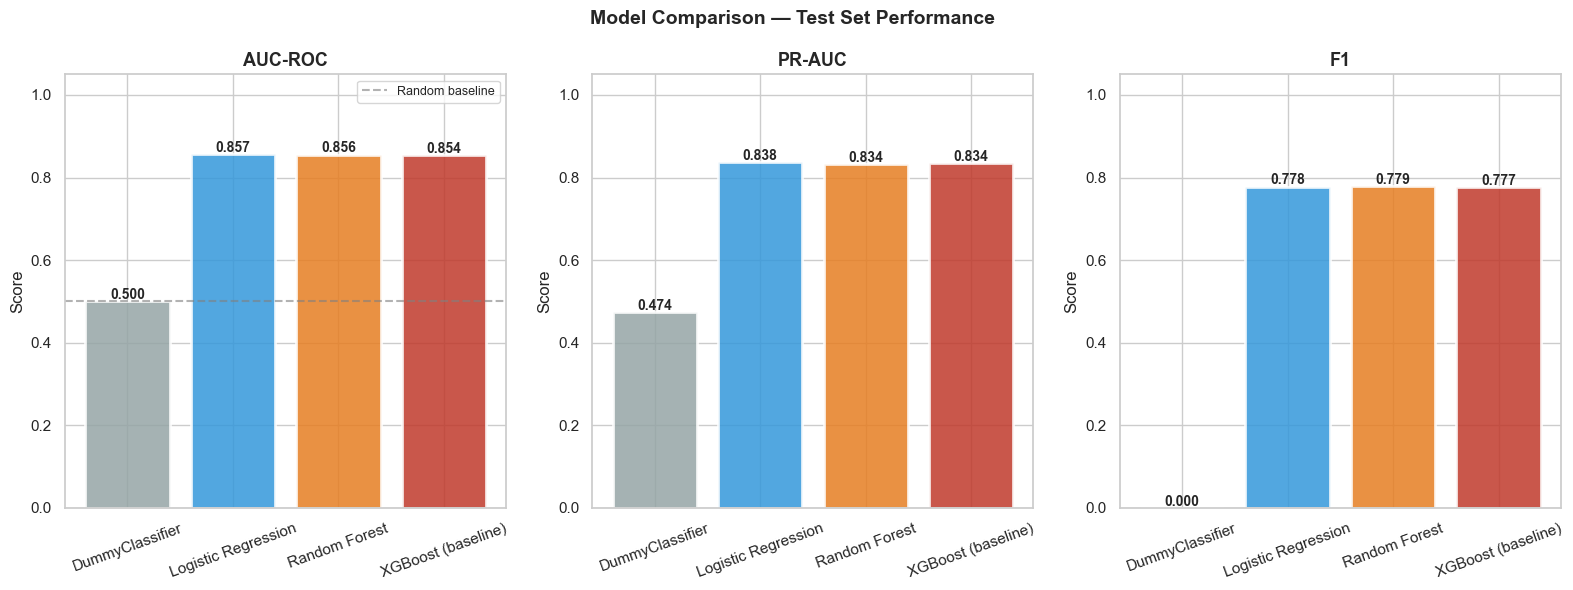


Best model by AUC-ROC : Logistic Regression


In [ ]:
print("── MODEL COMPARISON ──")

all_results = pd.DataFrame([
    baseline_results,
    lr_results,
    rf_results,
    xgb_results
])
all_results = all_results.set_index('Model')

# Highlight best value per metric
print(all_results.to_string())

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
metrics_to_plot = ['AUC-ROC', 'PR-AUC', 'F1']
colors = ['#95a5a6', '#3498db', '#e67e22', '#c0392b']
models = all_results.index.tolist()

for i, metric in enumerate(metrics_to_plot):
    values = all_results[metric].values
    bars = axes[i].bar(models, values,
                       color=colors, alpha=0.85,
                       edgecolor='white', linewidth=2)
    for bar, val in zip(bars, values):
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', fontsize=10, fontweight='bold'
        )
    axes[i].set_title(metric, fontweight='bold', fontsize=13)
    axes[i].set_ylim(0, 1.05)
    axes[i].set_ylabel('Score')
    axes[i].tick_params(axis='x', rotation=20)

    # Reference line at 0.5 for AUC-ROC
    if metric == 'AUC-ROC':
        axes[i].axhline(y=0.5, color='gray',
                        linestyle='--', alpha=0.6,
                        label='Random baseline')
        axes[i].legend(fontsize=9)

plt.suptitle('Model Comparison — Test Set Performance',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '16_model_comparison.png',
            bbox_inches='tight')
plt.show()

best_model = all_results['AUC-ROC'].idxmax()
print(f"\nBest model by AUC-ROC : {best_model}")

In [ ]:
print("── OPTUNA HYPERPARAMETER TUNING ──")
print("Searching best XGBoost parameters...")
print("This takes 3-5 minutes. Be patient.\n")

# Preprocessed train data for faster Optuna trials
# Fit preprocessor once — reuse across all trials
preprocessor_fitted = preprocessor.fit(X_train)
X_train_proc = preprocessor_fitted.transform(X_train)
X_test_proc  = preprocessor_fitted.transform(X_test)

def objective(trial: optuna.Trial) -> float:
    params = {
        'n_estimators'      : trial.suggest_int(
                                'n_estimators', 100, 800),
        'learning_rate'     : trial.suggest_float(
                                'learning_rate', 0.01, 0.3,
                                log=True),
        'max_depth'         : trial.suggest_int(
                                'max_depth', 3, 8),
        'min_child_weight'  : trial.suggest_int(
                                'min_child_weight', 1, 10),
        'subsample'         : trial.suggest_float(
                                'subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float(
                                'colsample_bytree', 0.5, 1.0),
        'reg_alpha'         : trial.suggest_float(
                                'reg_alpha', 0.0, 5.0),
        'reg_lambda'        : trial.suggest_float(
                                'reg_lambda', 1.0, 5.0),
        'scale_pos_weight'  : scale_pos_weight,
        'use_label_encoder' : False,
        'eval_metric'       : 'auc',
        'random_state'      : 42,
        'n_jobs'            : -1,
    }

    model = xgb.XGBClassifier(**params)

    scores = cross_val_score(
        model,
        X_train_proc, y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )
    return scores.mean()


study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✓ Optimization complete")
print(f"  Best AUC-ROC (CV) : {study.best_value:.4f}")
print(f"\nBest parameters :")
for param, value in study.best_params.items():
    print(f"  {param:<22} : {value}")

── OPTUNA HYPERPARAMETER TUNING ──
Searching best XGBoost parameters...
This takes 3-5 minutes. Be patient.



Best trial: 47. Best value: 0.864789: 100%|██████████| 50/50 [02:25<00:00,  2.91s/it]


✓ Optimization complete
  Best AUC-ROC (CV) : 0.8648

Best parameters :
  n_estimators           : 123
  learning_rate          : 0.06866416289227809
  max_depth              : 3
  min_child_weight       : 6
  subsample              : 0.9045549818989955
  colsample_bytree       : 0.888576877944646
  reg_alpha              : 2.050649476142385
  reg_lambda             : 2.092128095832243


In [ ]:
print("── TUNED XGBOOST ──")

best_params = study.best_params
best_params.update({
    'scale_pos_weight'  : scale_pos_weight,
    'use_label_encoder' : False,
    'eval_metric'       : 'auc',
    'random_state'      : 42,
    'n_jobs'            : -1,
})

xgb_tuned = xgb.XGBClassifier(**best_params)

# Final fit on full training set
xgb_tuned.fit(
    X_train_proc, y_train,
    eval_set=[(X_test_proc, y_test)],
    verbose=False
)

y_pred_tuned  = xgb_tuned.predict(X_test_proc)
y_proba_tuned = xgb_tuned.predict_proba(X_test_proc)[:, 1]

tuned_results = evaluate_model(
    'XGBoost (tuned)',
    y_test, y_pred_tuned, y_proba_tuned
)

print(f"\nTuned XGBoost — Test set results :")
for metric, value in tuned_results.items():
    if metric != 'Model':
        improvement = ""
        if metric == 'AUC-ROC':
            diff = value - xgb_results['AUC-ROC']
            improvement = f"  (+{diff:.4f} vs baseline)"
        print(f"  {metric:<12} : {value}{improvement}")

── TUNED XGBOOST ──

Tuned XGBoost — Test set results :
  AUC-ROC      : 0.861  (+0.0066 vs baseline)
  PR-AUC       : 0.8419
  F1           : 0.7813
  Precision    : 0.7494
  Recall       : 0.8161
  Accuracy     : 0.7834


── THRESHOLD OPTIMIZATION ──
Default threshold = 0.5 is rarely optimal.
We find the threshold that maximizes F1 score.

Optimal threshold : 0.47
F1 at threshold   : 0.7828
F1 at default 0.5 : 0.7813

Final results with optimal threshold :
  AUC-ROC      : 0.861
  PR-AUC       : 0.8419
  F1           : 0.7828
  Precision    : 0.7361
  Recall       : 0.8358
  Accuracy     : 0.78


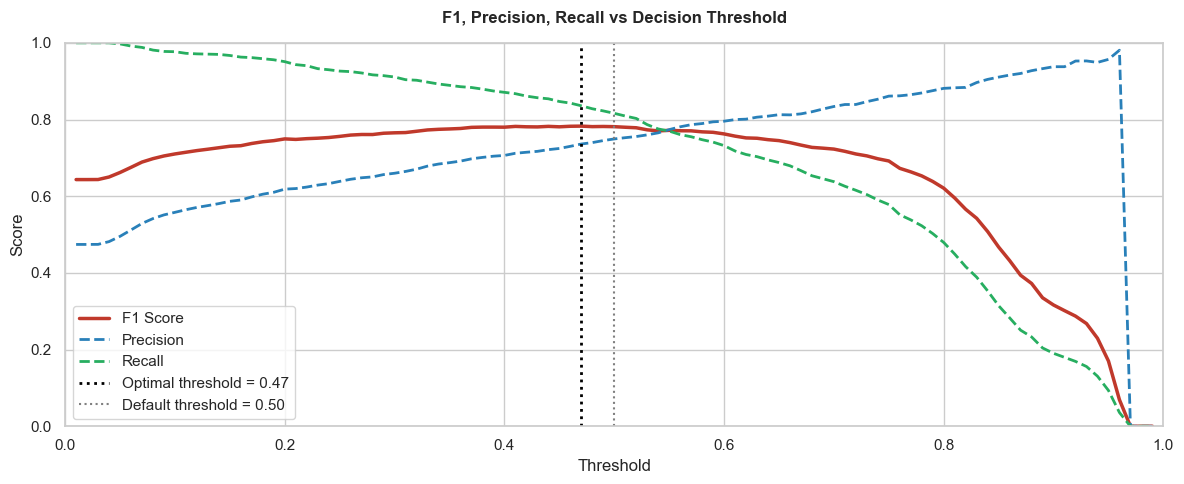

In [ ]:
print("── THRESHOLD OPTIMIZATION ──")
print("Default threshold = 0.5 is rarely optimal.")
print("We find the threshold that maximizes F1 score.\n")

thresholds  = np.arange(0.01, 1.0, 0.01)
f1_scores   = []
precision_scores = []
recall_scores    = []

for thresh in thresholds:
    y_pred_thresh = (y_proba_tuned >= thresh).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thresh,
                              zero_division=0))
    precision_scores.append(precision_score(y_test, y_pred_thresh,
                                            zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred_thresh,
                                      zero_division=0))

best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Optimal threshold : {best_threshold:.2f}")
print(f"F1 at threshold   : {best_f1:.4f}")
print(f"F1 at default 0.5 : {f1_scores[49]:.4f}")

# Apply optimal threshold
y_pred_optimal = (y_proba_tuned >= best_threshold).astype(int)
optimal_results = evaluate_model(
    f'XGBoost (threshold={best_threshold:.2f})',
    y_test, y_pred_optimal, y_proba_tuned
)

print(f"\nFinal results with optimal threshold :")
for metric, value in optimal_results.items():
    if metric != 'Model':
        print(f"  {metric:<12} : {value}")

# Plot threshold curve
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, f1_scores,
        color='#c0392b', linewidth=2.5, label='F1 Score')
ax.plot(thresholds, precision_scores,
        color='#2980b9', linewidth=2, label='Precision',
        linestyle='--')
ax.plot(thresholds, recall_scores,
        color='#27ae60', linewidth=2, label='Recall',
        linestyle='--')
ax.axvline(x=best_threshold, color='black',
           linestyle=':', linewidth=2,
           label=f'Optimal threshold = {best_threshold:.2f}')
ax.axvline(x=0.5, color='gray', linestyle=':',
           linewidth=1.5, label='Default threshold = 0.50')
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('F1, Precision, Recall vs Decision Threshold',
             fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '17_threshold_optimization.png',
            bbox_inches='tight')
plt.show()

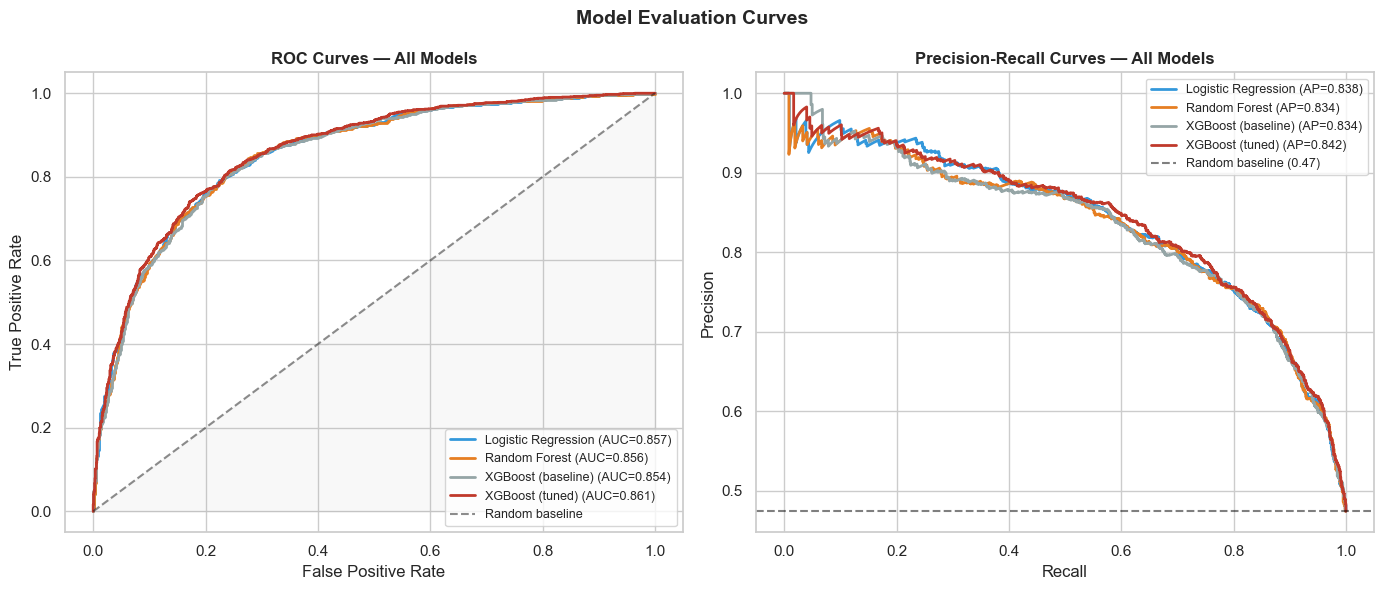

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_for_curves = {
    'Logistic Regression' : y_proba_lr,
    'Random Forest'       : y_proba_rf,
    'XGBoost (baseline)'  : y_proba_xgb,
    'XGBoost (tuned)'     : y_proba_tuned,
}
colors_curves = ['#3498db', '#e67e22', '#95a5a6', '#c0392b']

# ROC Curves
for (name, proba), color in zip(
    models_for_curves.items(), colors_curves
):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0,1], [0,1], 'k--', alpha=0.5,
             label='Random baseline')
axes[0].fill_between([0,1], [0,1], alpha=0.05, color='gray')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves — All Models',
                   fontweight='bold')
axes[0].legend(fontsize=9, loc='lower right')

# PR Curves
for (name, proba), color in zip(
    models_for_curves.items(), colors_curves
):
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, color=color, linewidth=2,
                 label=f'{name} (AP={ap:.3f})')

baseline_pr = y_test.mean()
axes[1].axhline(y=baseline_pr, color='black',
                linestyle='--', alpha=0.5,
                label=f'Random baseline ({baseline_pr:.2f})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves — All Models',
                   fontweight='bold')
axes[1].legend(fontsize=9, loc='upper right')

plt.suptitle('Model Evaluation Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '18_roc_pr_curves.png',
            bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default threshold 0.5
cm_default = confusion_matrix(y_test, y_pred_tuned)
disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cm_default,
    display_labels=['No Churn', 'Churn']
)
disp1.plot(ax=axes[0], colorbar=False, cmap='Reds')
axes[0].set_title(f'Confusion Matrix\nThreshold = 0.50',
                   fontweight='bold')

# Optimal threshold
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_optimal,
    display_labels=['No Churn', 'Churn']
)
disp2.plot(ax=axes[1], colorbar=False, cmap='Reds')
axes[1].set_title(
    f'Confusion Matrix\nThreshold = {best_threshold:.2f} (optimal)',
    fontweight='bold'
)

plt.suptitle('Confusion Matrix — Default vs Optimal Threshold',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '19_confusion_matrix.png',
            bbox_inches='tight')
plt.show()

# Business interpretation
tn, fp, fn, tp = cm_optimal.ravel()
print(f"\nBusiness interpretation at threshold "
      f"{best_threshold:.2f} :")
print(f"  True Positives  (caught churners)    : {tp:,}")
print(f"  False Negatives (missed churners)    : {fn:,}")
print(f"  False Positives (wrong alerts)       : {fp:,}")
print(f"  True Negatives  (correct non-churn)  : {tn:,}")
print(f"\n  Retention team outreach list size    : {tp+fp:,}")
print(f"  Churners correctly identified        : "
      f"{tp/(tp+fn)*100:.1f}% of all actual churners")

In [ ]:
print("── SAVING MODEL ARTIFACTS ──")

# Save the fitted preprocessor
joblib.dump(
    preprocessor_fitted,
    MODELS_PATH / 'preprocessor_v1.pkl'
)

# Save the tuned XGBoost model
joblib.dump(
    xgb_tuned,
    MODELS_PATH / 'xgboost_v1.pkl'
)

# Save model metadata
metadata = {
    'model_name'        : 'xgboost_v1',
    'algorithm'         : 'XGBoostClassifier',
    'trained_at'        : pd.Timestamp.now().isoformat(),
    'auc_roc'           : round(tuned_results['AUC-ROC'], 4),
    'pr_auc'            : round(tuned_results['PR-AUC'], 4),
    'f1_score'          : round(tuned_results['F1'], 4),
    'precision'         : round(tuned_results['Precision'], 4),
    'recall'            : round(tuned_results['Recall'], 4),
    'optimal_threshold' : round(float(best_threshold), 4),
    'scale_pos_weight'  : round(float(scale_pos_weight), 4),
    'n_features'        : int(X_train_proc.shape[1]),
    'train_size'        : int(len(X_train)),
    'test_size'         : int(len(X_test)),
    'churn_rate_train'  : round(float(y_train.mean()), 4),
    'best_params'       : best_params,
    'feature_names'     : feature_names,
}

with open(MODELS_PATH / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Artifacts saved in models/ :")
print(f"  preprocessor_v1.pkl    ← sklearn Pipeline")
print(f"  xgboost_v1.pkl         ← tuned XGBoost")
print(f"  model_metadata.json    ← metrics + params")

# Verify artifacts load correctly
prep_check  = joblib.load(MODELS_PATH / 'preprocessor_v1.pkl')
model_check = joblib.load(MODELS_PATH / 'xgboost_v1.pkl')
test_pred   = model_check.predict_proba(
    prep_check.transform(X_test[:5])
)[:, 1]
print(f"\n✓ Artifacts verified — sample predictions :")
print(f"  {test_pred.round(3)}")

── SAVING MODEL ARTIFACTS ──
Artifacts saved in models/ :
  preprocessor_v1.pkl    ← sklearn Pipeline
  xgboost_v1.pkl         ← tuned XGBoost
  model_metadata.json    ← metrics + params

✓ Artifacts verified — sample predictions :
  [0.954 0.671 0.081 0.064 0.186]


In [ ]:
print("═" * 60)
print("  FINAL MODEL COMPARISON — ALL MODELS")
print("═" * 60)

final_comparison = pd.DataFrame([
    baseline_results,
    lr_results,
    rf_results,
    xgb_results,
    tuned_results,
    optimal_results,
]).set_index('Model')

print(final_comparison.to_string())

print(f"\n{'═'*60}")
print(f"  SELECTED MODEL SUMMARY")
print(f"{'═'*60}")
print(f"  Algorithm       : XGBoost (tuned + threshold optimized)")
print(f"  AUC-ROC         : {optimal_results['AUC-ROC']}")
print(f"  PR-AUC          : {optimal_results['PR-AUC']}")
print(f"  F1 Score        : {optimal_results['F1']}")
print(f"  Precision       : {optimal_results['Precision']}")
print(f"  Recall          : {optimal_results['Recall']}")
print(f"  Threshold       : {best_threshold:.2f}")
print(f"  scale_pos_weight: {scale_pos_weight:.2f}")

print(f"{'═'*60}")

════════════════════════════════════════════════════════════
  FINAL MODEL COMPARISON — ALL MODELS
════════════════════════════════════════════════════════════
                          AUC-ROC  PR-AUC      F1  Precision  Recall  Accuracy
Model                                                                         
DummyClassifier            0.5000  0.4742  0.0000     0.0000  0.0000    0.5258
Logistic Regression        0.8567  0.8377  0.7783     0.7393  0.8218    0.7780
Random Forest              0.8558  0.8337  0.7786     0.7479  0.8119    0.7810
XGBoost (baseline)         0.8544  0.8343  0.7773     0.7497  0.8070    0.7807
XGBoost (tuned)            0.8610  0.8419  0.7813     0.7494  0.8161    0.7834
XGBoost (threshold=0.47)   0.8610  0.8419  0.7828     0.7361  0.8358    0.7800

════════════════════════════════════════════════════════════
  SELECTED MODEL SUMMARY
════════════════════════════════════════════════════════════
  Algorithm       : XGBoost (tuned + threshold optimized)
  